## What this notebook is doing differently from a fixed top-5 basket

A 45 / 30 / 10 / 10 / 5 BTC-ETH-SOL-XRP-ADA basket is a static methodology. The numbers are picked once and applied forever. Two problems:

1. The constituent count is not justified by data. There is no test that says "five tokens is enough".
2. The basket cannot react when the universe changes (e.g. a new top-10 token appears, a stablecoin de-pegs, an old token loses liquidity).

The LC rule fixes both: $K^*$ is chosen from the data, and the choice is repeated every month. The plotted $K^*$ series shows that the answer is **not constant**, which is exactly why a fixed-size methodology is fragile.

**Limitations** (intentional, for transparency)
- We rank by a market-cap proxy (close × snapshot circulating supply). Real CRIX uses traded volume on regulated venues, which is what makes the LC piece a *liquidity* criterion in the strict sense.
- We do not implement the AIC piece of CRIX. On this 20-token, BTC-dominated universe the textbook 2K penalty is degenerate — see the discussion at the top of this notebook.
- We do not handle airdrops, hard-forks or stablecoin de-pegging.

Next notebook builds GARCH volatility on top of this basket.

# 1. CRIX-style basket: pick the number of constituents from data, not from convention

A fixed top-5 basket is a guess. CRIX (Trimborn & Härdle 2018, *JEF* 49) lets the data decide how many tokens belong inside the index. The CRIX procedure has two pieces: a **liquidity criterion (LC)** that ranks tokens by tradability, and an **information criterion (AIC)** that picks how many of them to keep. We reproduce the LC piece on a 20-token universe with daily yfinance data.

**Why only the LC piece here?** With a small, very BTC-dominated universe, the textbook AIC selection (penalty 2K) is degenerate: BTC and ETH together already explain >99% of the value-weighted return, so adding more constituents reduces RSS at rates that the 2K penalty cannot offset. AIC then picks the maximum K every month. A faithful AIC implementation needs a different likelihood model — outside the scope of a 1-day demo. The LC piece on its own already produces a non-trivial, time-varying basket and that is what matters for the PPT discussion.

**Steps**
1. Pull daily closes for a 20-token universe.
2. At each month-end rebalance, rank tokens by 90-day average dollar volume.
3. Take the smallest $K^*$ such that the top-$K^*$ tokens cover $\ge 90\%$ of total dollar volume.
4. Track how $K^*$ moves through time and rebuild the basket index level.

The point is the same as in CRIX: **the size of the index is a parameter the data should choose**, not a number written into the methodology document.

In [24]:
# !pip install yfinance pandas numpy matplotlib  # uncomment on Colab
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [25]:
# Universe: 20 tokens that have continuous coverage on yfinance since 2022
universe = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'XRP-USD',
    'ADA-USD', 'DOGE-USD', 'AVAX-USD', 'DOT-USD', 'TRX-USD',
    'LINK-USD', 'LTC-USD', 'BCH-USD', 'ATOM-USD', 'XLM-USD',
    'ETC-USD', 'NEAR-USD', 'HBAR-USD', 'FIL-USD', 'ALGO-USD'
]

# Approximate circulating supply (snapshot, 2026Q1; mid-cap proxy).
# Source: CoinGecko ranges; rounded — only used for relative cap weighting.
supply = pd.Series({
    'BTC-USD':  19.7e6,   'ETH-USD':  120e6,    'BNB-USD':  145e6,
    'SOL-USD':  470e6,    'XRP-USD':   57e9,    'ADA-USD':   35e9,
    'DOGE-USD': 145e9,    'AVAX-USD': 410e6,    'DOT-USD':   1.4e9,
    'TRX-USD':   90e9,    'LINK-USD': 660e6,    'LTC-USD':   75e6,
    'BCH-USD':  19.8e6,   'ATOM-USD': 390e6,    'XLM-USD':   29e9,
    'ETC-USD':  150e6,    'NEAR-USD': 1.1e9,    'HBAR-USD':  38e9,
    'FIL-USD':  660e6,    'ALGO-USD': 8.5e9,
})

raw = yf.download(
    universe, start='2022-01-01', auto_adjust=True, progress=False
)
close = raw['Close'].dropna(how='all').ffill(limit=2)
volume = raw['Volume'].reindex(close.index).fillna(0.0)
dollar_vol = close * volume

# Market-cap proxy: daily close × snapshot circulating supply. Imperfect
# (supply was not constant historically) but defensible for a demo and far
# less BTC-concentrated than yfinance's reported dollar volume.
mcap = close.multiply(supply.reindex(close.columns), axis=1)

print('Coverage:', close.index.min().date(), '→', close.index.max().date())
print('Tokens with at least 90% data:', (close.notna().mean() > 0.9).sum(), '/', len(universe))
latest_mcap = mcap.iloc[-1].dropna().sort_values(ascending=False)
print('\nLatest market-cap proxy ($B), top 5:')
for tok, m in latest_mcap.head(5).items():
    print(f'  {tok:10s} {m/1e9:8.1f}')

Coverage: 2022-01-01 → 2026-06-14
Tokens with at least 90% data: 20 / 20

Latest market-cap proxy ($B), top 5:
  BTC-USD      1262.5
  ETH-USD       199.3
  BNB-USD        88.0
  XRP-USD        64.6
  SOL-USD        31.7


In [26]:
# Daily log returns
log_ret = np.log(close / close.shift(1))

# Liquidity-coverage selection (the LC piece of CRIX).
# Pick the smallest K such that the top-K tokens by 90-day mean market-cap proxy
# cover >= COVERAGE_TARGET of total cap in the window.
COVERAGE_TARGET = 0.90

def lc_pick_K(window_metric, coverage=COVERAGE_TARGET):
    sorted_m = window_metric.sort_values(ascending=False)
    cum = sorted_m.cumsum() / sorted_m.sum()
    K = int((cum < coverage).sum()) + 1
    return min(K, len(sorted_m)), sorted_m.index[:K].tolist()

In [27]:
# Monthly rebalance: at each month-end use the prior 90 days to pick K*.
try:
    rebal_dates = pd.date_range(close.index.min(), close.index.max(), freq='ME')
except ValueError:
    rebal_dates = pd.date_range(close.index.min(), close.index.max(), freq='M')
rebal_dates = rebal_dates[rebal_dates >= close.index.min() + pd.Timedelta(days=120)]

K_star_history = {}
members_history = {}

for d in rebal_dates:
    win_log_ret = log_ret.loc[d - pd.Timedelta(days=90):d].dropna(axis=1, how='all')
    if len(win_log_ret) < 60:
        continue
    win_mcap = mcap.loc[d - pd.Timedelta(days=90):d][win_log_ret.columns].mean()
    win_mcap = win_mcap.dropna()
    win_mcap = win_mcap[win_mcap > 0]
    K_star, members = lc_pick_K(win_mcap, COVERAGE_TARGET)
    K_star_history[d] = K_star
    members_history[d] = members

K_series = pd.Series(K_star_history).sort_index()
print(f'Coverage target: {int(COVERAGE_TARGET*100)}% of basket market-cap proxy')
print(f'K* range: {K_series.min()} to {K_series.max()}')
print(f'Most recent rebalance: {K_series.index[-1].date()} with K* = {K_series.iloc[-1]}')
print('Members on last rebalance:')
for m in members_history[K_series.index[-1]]:
    print(f'  - {m}')

Coverage target: 90% of basket market-cap proxy
K* range: 4 to 7
Most recent rebalance: 2026-05-31 with K* = 4
Members on last rebalance:
  - BTC-USD
  - ETH-USD
  - BNB-USD
  - XRP-USD


In [28]:
close.head()

Ticker,ADA-USD,ALGO-USD,ATOM-USD,AVAX-USD,BCH-USD,BNB-USD,BTC-USD,DOGE-USD,DOT-USD,ETC-USD,ETH-USD,FIL-USD,HBAR-USD,LINK-USD,LTC-USD,NEAR-USD,SOL-USD,TRX-USD,XLM-USD,XRP-USD
Date,,,,,,,,,,,,,,,,,,,,
2022-01-01,1.376975,1.740108,36.170464,114.158012,444.456177,527.352722,47686.812500,0.173035,28.583582,34.868908,3769.697021,35.854889,0.300890,20.665089,150.697433,15.169566,178.517944,0.076610,0.276335,0.849472
2022-01-02,1.377584,1.674041,35.603455,113.186333,447.832642,531.396667,47345.218750,0.174403,29.731167,35.396397,3829.564941,35.792622,0.312153,21.831890,151.255493,14.410521,176.382843,0.077782,0.291703,0.859118
2022-01-03,1.321637,1.788210,39.300068,108.145210,434.943848,512.135986,46458.117188,0.170088,30.105101,34.707752,3761.380371,35.020367,0.306500,23.573906,148.461594,16.429792,170.297745,0.077081,0.290181,0.832885
2022-01-04,1.311658,1.674683,41.987125,103.239243,427.524323,507.506104,45897.574219,0.168803,28.777731,34.171375,3794.056641,36.098606,0.325898,23.525866,146.812286,16.014059,167.938904,0.076200,0.279667,0.824673
2022-01-05,1.236002,1.559897,38.793358,97.852577,401.572510,475.056946,43569.003906,0.159420,26.796141,32.077309,3550.386963,33.258137,0.288261,25.447802,136.089111,15.379840,155.099731,0.071382,0.267280,0.774358


In [29]:
basket_cols = [c for c in close.columns if c != 'BTC-USD']

basket_norm = close[basket_cols].div(close[basket_cols].iloc[0]) * 100
basket_index = basket_norm.mean(axis=1)

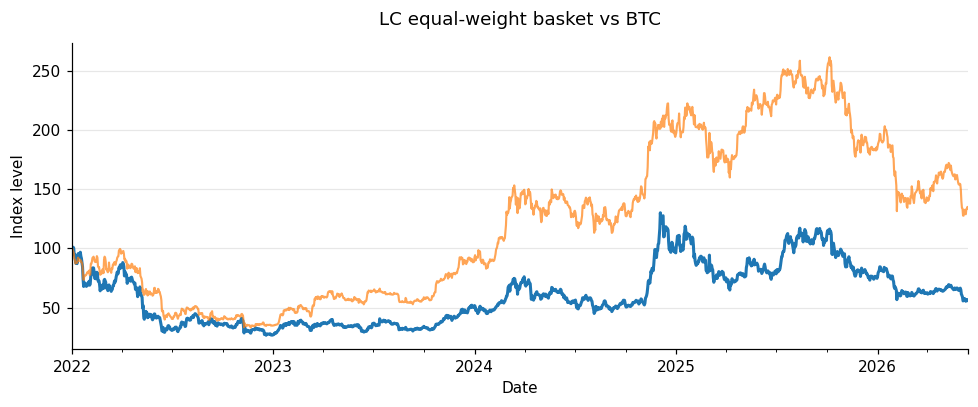

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.8))

btc_norm = (close['BTC-USD'] / close['BTC-USD'].loc[basket_index.index[0]]) * 100

basket_index.plot(ax=ax, label='LC equal-weight basket', linewidth=2)
btc_norm.loc[basket_index.index].plot(
    ax=ax,
    label='BTC (rebased to 100)',
    linewidth=1.4,
    alpha=0.7
)

ax.set_title('LC equal-weight basket vs BTC', pad=12)
ax.set_ylabel('Index level')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(
    'fig_basket_vs_btc.png',
    dpi=200,
    bbox_inches='tight',
    transparent=True
)
plt.show()

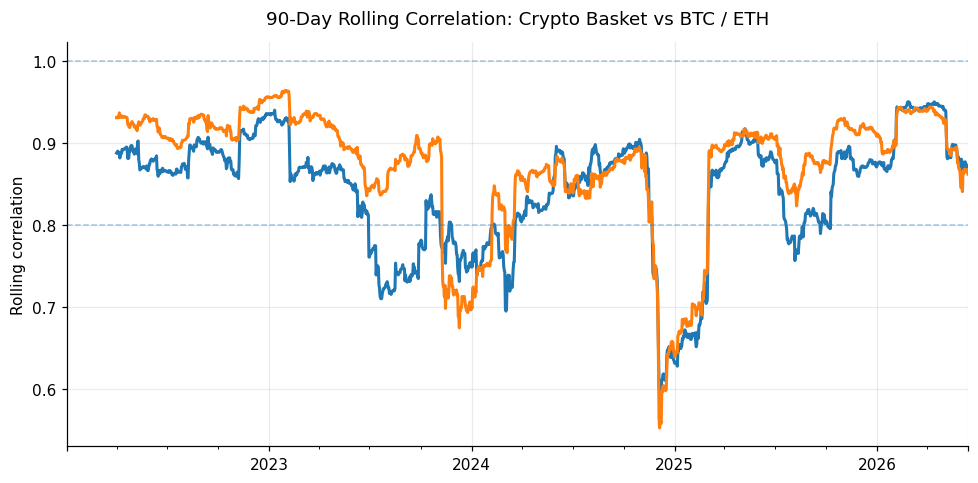

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# calculate returns
log_ret = np.log(close / close.shift(1)).dropna()
basket_ret = np.log(basket_index / basket_index.shift(1)).dropna()

# Rolling correlation: basket vs BTC / ETH
rolling_window = 90

corr_data = pd.DataFrame({
    "Basket": basket_ret,
    "BTC": log_ret["BTC-USD"],
    "ETH": log_ret["ETH-USD"]
}).dropna()

rolling_corr_btc = corr_data["Basket"].rolling(rolling_window).corr(corr_data["BTC"])
rolling_corr_eth = corr_data["Basket"].rolling(rolling_window).corr(corr_data["ETH"])

fig, ax = plt.subplots(figsize=(9, 4.5))

rolling_corr_btc.plot(ax=ax, label="Basket vs BTC", linewidth=2)
rolling_corr_eth.plot(ax=ax, label="Basket vs ETH", linewidth=2)

ax.set_title("90-Day Rolling Correlation: Crypto Basket vs BTC / ETH", pad=12)
ax.set_ylabel("Rolling correlation")
ax.set_xlabel("")
ax.axhline(1.0, linestyle="--", linewidth=1, alpha=0.4)
ax.axhline(0.8, linestyle="--", linewidth=1, alpha=0.4)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(
    "fig_rolling_correlation_basket_btc_eth.png",
    dpi=250,
    bbox_inches="tight",
    transparent=True
)
plt.show()

In [11]:
# Tail-risk comparison: BTC vs ETH vs Basket

risk_returns = pd.DataFrame({
    "BTC": log_ret["BTC-USD"],
    "ETH": log_ret["ETH-USD"],
    "Crypto Basket": basket_ret
}).dropna()

def max_drawdown_from_returns(r):
    wealth_index = np.exp(r.cumsum())
    running_max = wealth_index.cummax()
    drawdown = wealth_index / running_max - 1
    return drawdown.min()

def tail_risk_stats(r, alpha=0.05):
    var = r.quantile(alpha)
    es = r[r <= var].mean()
    mdd = max_drawdown_from_returns(r)
    ann_vol = r.std() * np.sqrt(365)
    ann_return = r.mean() * 365
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
    
    return pd.Series({
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "VaR 5%": var,
        "ES 5%": es,
        "Max Drawdown": mdd,
        "Sharpe": sharpe
    })

risk_table = risk_returns.apply(tail_risk_stats).T

risk_table

,Annualized Return,Annualized Volatility,VaR 5%,ES 5%,Max Drawdown,Sharpe
BTC,0.224991,0.496978,-0.037583,-0.060292,-0.503424,0.452719
ETH,0.017025,0.683759,-0.054789,-0.084799,-0.637877,0.024899
Crypto Basket,0.007098,0.576712,-0.046669,-0.072448,-0.554795,0.012308


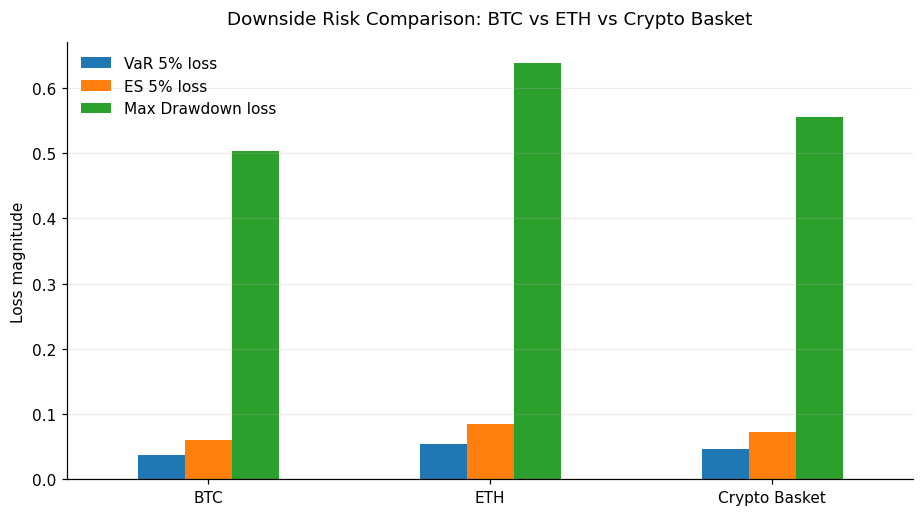

In [14]:
# Positive loss version for PPT

tail_loss = pd.DataFrame({
    "VaR 5% loss": -risk_table["VaR 5%"],
    "ES 5% loss": -risk_table["ES 5%"],
    "Max Drawdown loss": -risk_table["Max Drawdown"]
})

fig, ax = plt.subplots(figsize=(8.5, 4.8))

tail_loss.plot(kind="bar", ax=ax)

ax.set_title("Downside Risk Comparison: BTC vs ETH vs Crypto Basket", pad=12)
ax.set_ylabel("Loss magnitude")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "fig_downside_risk_comparison.png",
    dpi=250,
    bbox_inches="tight",
    transparent=True
)
plt.show()

In [15]:
# Construct alternative basket designs for similarity comparison

top5 = ["BTC-USD", "ETH-USD", "SOL-USD", "XRP-USD", "ADA-USD"]

# 1. Fixed top-5 equal-weight basket
top5_equal_ret = log_ret[top5].mean(axis=1)

# 2. Fixed top-5 cap-weight proxy basket
latest_mcap_top5 = mcap[top5].dropna().iloc[-1]
top5_cap_weights = latest_mcap_top5 / latest_mcap_top5.sum()

top5_cap_ret = log_ret[top5].mul(top5_cap_weights, axis=1).sum(axis=1)

# Combine return series
similarity_returns = pd.DataFrame({
    "BTC": log_ret["BTC-USD"],
    "ETH": log_ret["ETH-USD"],
    "LC Equal-Weight Basket": basket_ret,
    "Top-5 Equal-Weight": top5_equal_ret,
    "Top-5 Cap-Weight": top5_cap_ret
}).dropna()

corr_matrix = similarity_returns.corr()

corr_matrix

,BTC,ETH,LC Equal-Weight Basket,Top-5 Equal-Weight,Top-5 Cap-Weight
BTC,1.000000,0.836512,0.894925,0.872020,0.990834
ETH,0.836512,1.000000,0.913538,0.890406,0.894945
LC Equal-Weight Basket,0.894925,0.913538,1.000000,0.961247,0.937332
Top-5 Equal-Weight,0.872020,0.890406,0.961247,1.000000,0.921830
Top-5 Cap-Weight,0.990834,0.894945,0.937332,0.921830,1.000000


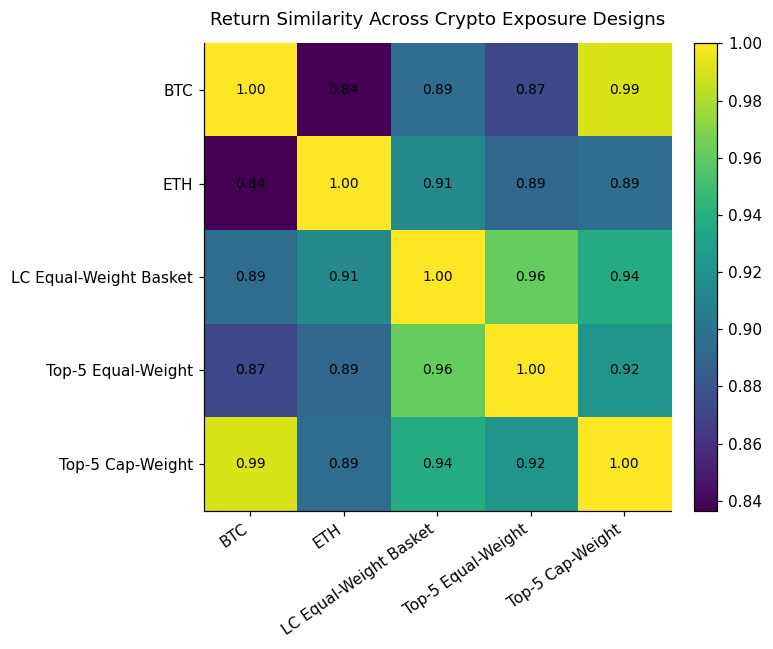

In [16]:
# Correlation heatmap without seaborn

fig, ax = plt.subplots(figsize=(7.2, 6))

im = ax.imshow(corr_matrix.values)

ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))

ax.set_xticklabels(corr_matrix.columns, rotation=35, ha="right")
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

ax.set_title("Return Similarity Across Crypto Exposure Designs", pad=12)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(
    "fig_crypto_exposure_correlation_heatmap.png",
    dpi=250,
    bbox_inches="tight",
    transparent=True
)
plt.show()

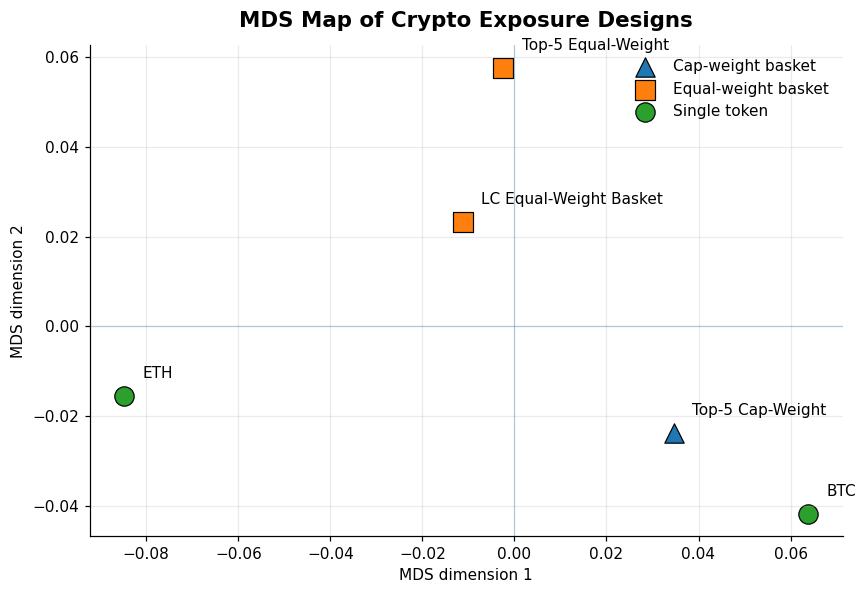

In [22]:
from sklearn.manifold import MDS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Distance matrix from correlation
distance_matrix = 1 - corr_matrix

mds = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=42,
    n_init=4
)

coords = mds.fit_transform(distance_matrix)

mds_df = pd.DataFrame(
    coords,
    index=corr_matrix.index,
    columns=["MDS1", "MDS2"]
)

# Add simple groups
groups = {
    "BTC": "Single token",
    "ETH": "Single token",
    "LC Equal-Weight Basket": "Equal-weight basket",
    "Top-5 Equal-Weight": "Equal-weight basket",
    "Top-5 Cap-Weight": "Cap-weight basket"
}

mds_df["Group"] = mds_df.index.map(groups)

fig, ax = plt.subplots(figsize=(8, 5.5))

markers = {
    "Single token": "o",
    "Equal-weight basket": "s",
    "Cap-weight basket": "^"
}

for group, data in mds_df.groupby("Group"):
    ax.scatter(
        data["MDS1"],
        data["MDS2"],
        s=160,
        marker=markers[group],
        label=group,
        edgecolor="black",
        linewidth=0.8
    )

for label, row in mds_df.iterrows():
    ax.text(
        row["MDS1"] + 0.004,
        row["MDS2"] + 0.004,
        label,
        fontsize=10
    )

ax.set_title(
    "MDS Map of Crypto Exposure Designs",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("MDS dimension 1")
ax.set_ylabel("MDS dimension 2")

ax.axhline(0, linewidth=0.8, alpha=0.3)
ax.axvline(0, linewidth=0.8, alpha=0.3)
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc="best")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "fig_mds_crypto_exposure_designs_ppt.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [32]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure BTC column name is correct
btc_col = "BTC-USD" if "BTC-USD" in log_ret.columns else "BTC"
eth_col = "ETH-USD" if "ETH-USD" in log_ret.columns else "ETH"

# Build return table for different exposure designs
methodology_returns = pd.DataFrame({
    "BTC": log_ret[btc_col],
    "ETH": log_ret[eth_col],
    "LC Basket": basket_ret,
    "Top-5 Cap-Weight": top5_cap_ret,
    "Top-5 Capped 40%": top5_capped_ret,
    "Top-5 Equal-Weight": top5_equal_ret
}).dropna()

# Run BTC beta regression:
# r_index,t = alpha + beta_BTC * r_BTC,t + epsilon_t

btc_beta_results = []

for col in methodology_returns.columns:
    if col == "BTC":
        continue
    
    data = methodology_returns[["BTC", col]].dropna()
    
    y = data[col]
    X = sm.add_constant(data["BTC"])
    
    model = sm.OLS(y, X).fit()
    
    btc_beta_results.append({
        "Index Design": col,
        "BTC Beta": model.params["BTC"],
        "R-squared": model.rsquared,
        "Alpha": model.params["const"]
    })

btc_beta_table = pd.DataFrame(btc_beta_results)

btc_beta_table

,Index Design,BTC Beta,R-squared,Alpha
0,ETH,1.150902,0.699753,-0.000663
1,LC Basket,1.038505,0.800890,-0.000621
2,Top-5 Cap-Weight,1.029316,0.981752,-0.000096
3,Top-5 Capped 40%,1.087508,0.870802,-0.000285
4,Top-5 Equal-Weight,1.147325,0.760419,-0.000438


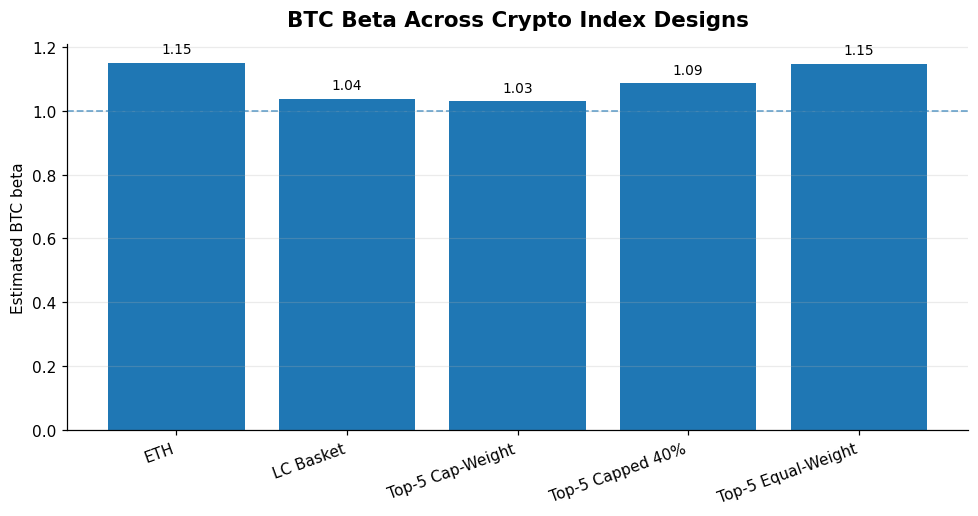

In [33]:
fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.bar(
    btc_beta_table["Index Design"],
    btc_beta_table["BTC Beta"]
)

ax.axhline(1, linestyle="--", linewidth=1.2, alpha=0.6)

ax.set_title(
    "BTC Beta Across Crypto Index Designs",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_ylabel("Estimated BTC beta")
ax.set_xlabel("")

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    "fig_btc_beta_across_index_designs.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

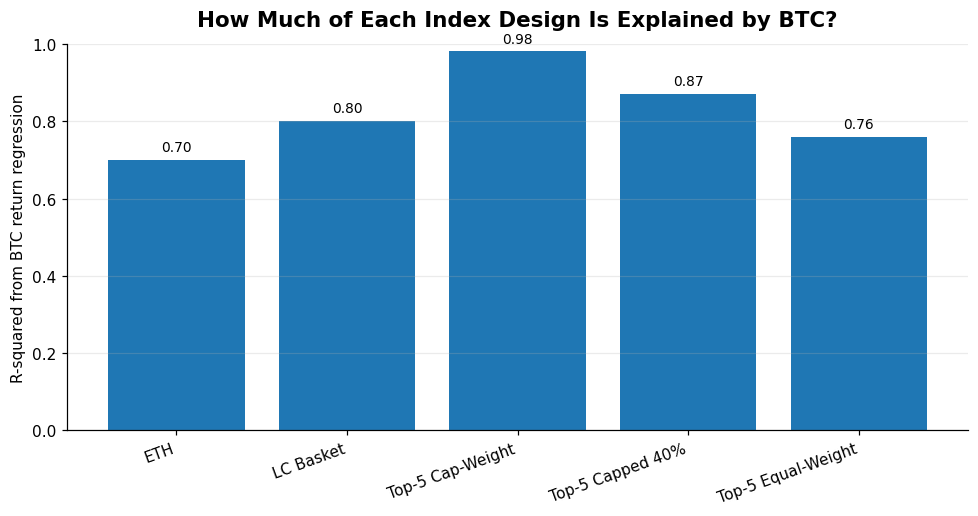

In [34]:
fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.bar(
    btc_beta_table["Index Design"],
    btc_beta_table["R-squared"]
)

ax.set_title(
    "How Much of Each Index Design Is Explained by BTC?",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_ylabel("R-squared from BTC return regression")
ax.set_xlabel("")
ax.set_ylim(0, 1)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    "fig_btc_r_squared_across_index_designs.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [35]:
# Tail dependence check: does diversification work during BTC crash days?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = methodology_returns.dropna()

# Define BTC crash days as the worst 5% BTC return days
btc_crash_threshold = data["BTC"].quantile(0.05)
crash_days = data["BTC"] <= btc_crash_threshold
normal_days = data["BTC"] > btc_crash_threshold

tail_results = []

for col in data.columns:
    if col == "BTC":
        continue
    
    normal_corr = data.loc[normal_days, ["BTC", col]].corr().iloc[0, 1]
    crash_corr = data.loc[crash_days, ["BTC", col]].corr().iloc[0, 1]
    
    avg_normal_return = data.loc[normal_days, col].mean()
    avg_crash_return = data.loc[crash_days, col].mean()
    
    tail_results.append({
        "Index Design": col,
        "Normal Corr with BTC": normal_corr,
        "Crash Corr with BTC": crash_corr,
        "Avg Return on Normal Days": avg_normal_return,
        "Avg Return on BTC Crash Days": avg_crash_return
    })

tail_dependence_table = pd.DataFrame(tail_results)

tail_dependence_table

,Index Design,Normal Corr with BTC,Crash Corr with BTC,Avg Return on Normal Days,Avg Return on BTC Crash Days
0,ETH,0.783711,0.755205,0.004011,-0.074842
1,LC Basket,0.862052,0.785397,0.003602,-0.067654
2,Top-5 Cap-Weight,0.987537,0.981136,0.003912,-0.063176
3,Top-5 Capped 40%,0.909798,0.873153,0.004053,-0.068900
4,Top-5 Equal-Weight,0.835964,0.725898,0.004177,-0.073550


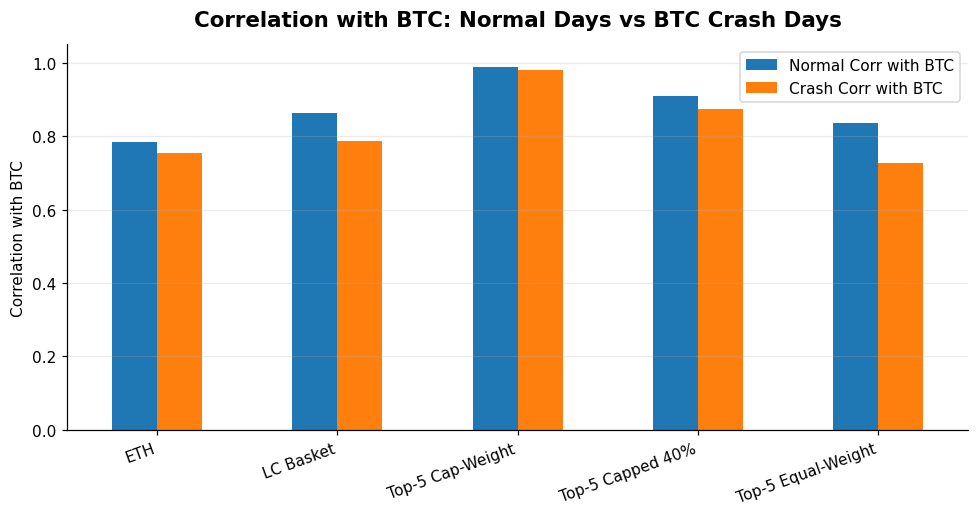

In [36]:
plot_corr = tail_dependence_table.set_index("Index Design")[
    ["Normal Corr with BTC", "Crash Corr with BTC"]
]

fig, ax = plt.subplots(figsize=(9, 4.8))

plot_corr.plot(kind="bar", ax=ax)

ax.set_title(
    "Correlation with BTC: Normal Days vs BTC Crash Days",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_ylabel("Correlation with BTC")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    "fig_tail_dependence_normal_vs_crash_correlation.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

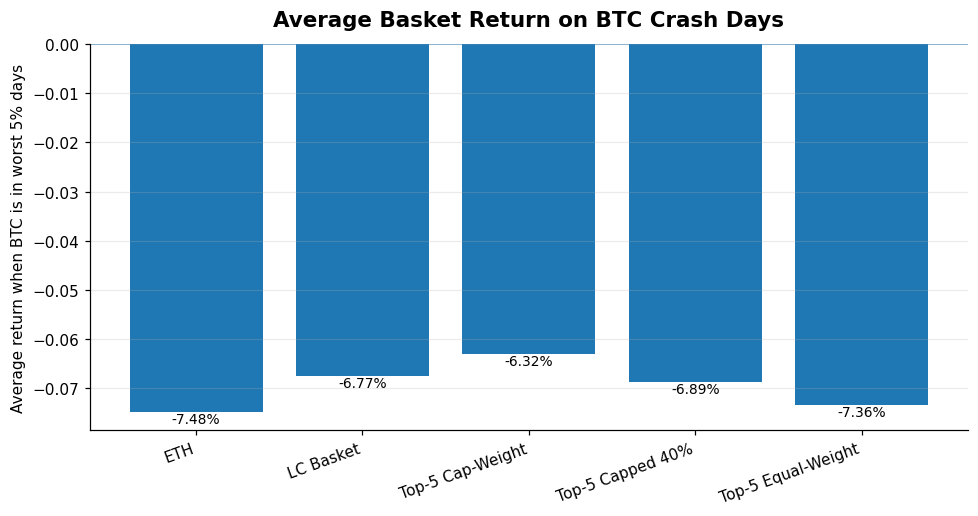

In [37]:
plot_loss = tail_dependence_table.set_index("Index Design")[
    "Avg Return on BTC Crash Days"
]

fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.bar(
    plot_loss.index,
    plot_loss.values
)

ax.axhline(0, linewidth=1, alpha=0.6)

ax.set_title(
    "Average Basket Return on BTC Crash Days",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_ylabel("Average return when BTC is in worst 5% days")
ax.set_xlabel("")

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2%}",
        ha="center",
        va="top" if height < 0 else "bottom",
        fontsize=9
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    "fig_average_return_on_btc_crash_days.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

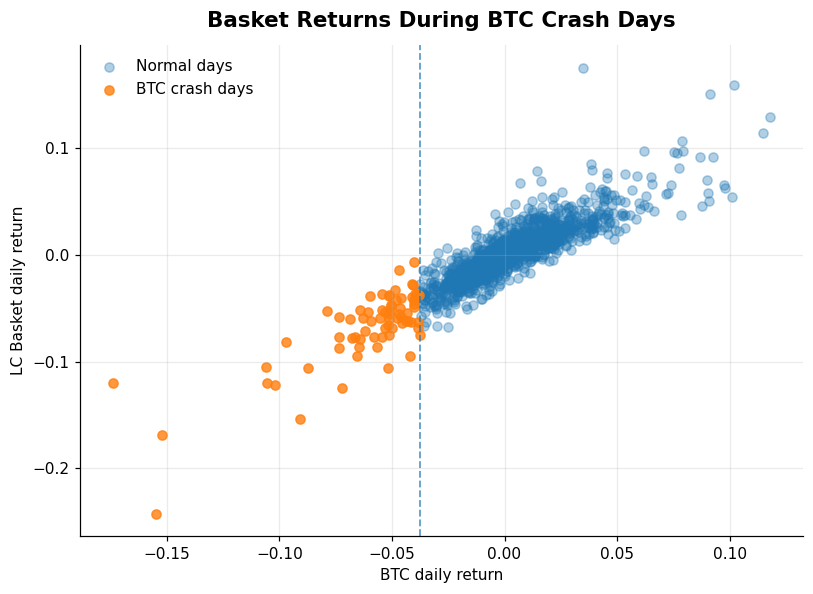

In [38]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

basket_name = "LC Basket"

ax.scatter(
    data.loc[normal_days, "BTC"],
    data.loc[normal_days, basket_name],
    alpha=0.35,
    label="Normal days"
)

ax.scatter(
    data.loc[crash_days, "BTC"],
    data.loc[crash_days, basket_name],
    alpha=0.8,
    label="BTC crash days"
)

ax.axvline(btc_crash_threshold, linestyle="--", linewidth=1.2, alpha=0.7)

ax.set_title(
    "Basket Returns During BTC Crash Days",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("BTC daily return")
ax.set_ylabel(f"{basket_name} daily return")

ax.grid(alpha=0.25)
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "fig_basket_returns_during_btc_crash_days.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()